In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [ ]:

import pandas as pd
import numpy as np

try:
    df = pd.read_csv('Telco Customer Churn.csv')
except Exception:
    try:
        from google.colab import files
        uploaded = files.upload()
        fname = list(uploaded.keys())[0]
        df = pd.read_csv(fname)
    except Exception:
        df = pd.read_csv('Telco-Customer-Churn.csv')

print(df.shape)
df.head()


Saving Telco Customer Churn.csv to Telco Customer Churn.csv
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:

if df['Churn'].dtype == object:
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['CLV'] = df['MonthlyCharges'] * df['tenure']


In [ ]:

from sklearn.preprocessing import LabelEncoder
label_encoders = {}
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in ('customerID',)]
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le



In [ ]:

from sklearn.model_selection import train_test_split
X = df.drop(['customerID','Churn'], axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [ ]:

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
from sklearn.metrics import accuracy_score, classification_report
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf)*100,2), "%")


Random Forest Accuracy: 79.33 %


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_model = LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_log)*100,2), "%")
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 81.03 %
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1282
           1       0.69      0.56      0.62       479

    accuracy                           0.81      1761
   macro avg       0.77      0.73      0.75      1761
weighted avg       0.80      0.81      0.80      1761



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.783

Confusion Matrix:
 [[1137  145]
 [ 238  241]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1282
           1       0.62      0.50      0.56       479

    accuracy                           0.78      1761
   macro avg       0.73      0.70      0.71      1761
weighted avg       0.77      0.78      0.77      1761



In [ ]:

df['RF_Churn_Prob']  = rf_model.predict_proba(X)[:,1]
df['Log_Churn_Prob'] = log_model.predict_proba(scaler.transform(X))[:,1]
df['XGB_Churn_Prob'] = xgb_model.predict_proba(X)[:,1]


In [ ]:

if 'Contract' in label_encoders:
    mapping_back = {i: label for i, label in enumerate(label_encoders['Contract'].classes_)}
    df['Contract'] = df['Contract'].map(mapping_back)
else:
    df['Contract'] = df['Contract'].map({0:'Month-to-month',1:'One year',2:'Two year'}).fillna(df['Contract'])

# Gender label
if 'gender' in label_encoders:
    gender_map = {i: label for i, label in enumerate(label_encoders['gender'].classes_)}
    df['Gender_Label'] = df['gender'].map(gender_map)
else:
    df['Gender_Label'] = df['gender'].map({0:'Female',1:'Male'}).fillna(df['gender'])


In [ ]:

churn_rate = round(df['Churn'].mean(), 4)
df['Churn_Rate'] = churn_rate
print("Overall churn rate (decimal):", churn_rate)


Overall churn rate (decimal): 0.2654


<Figure size 1000x600 with 0 Axes>

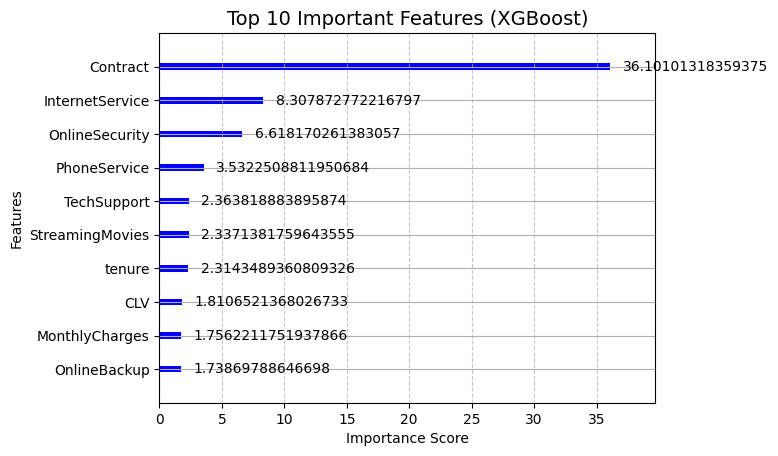

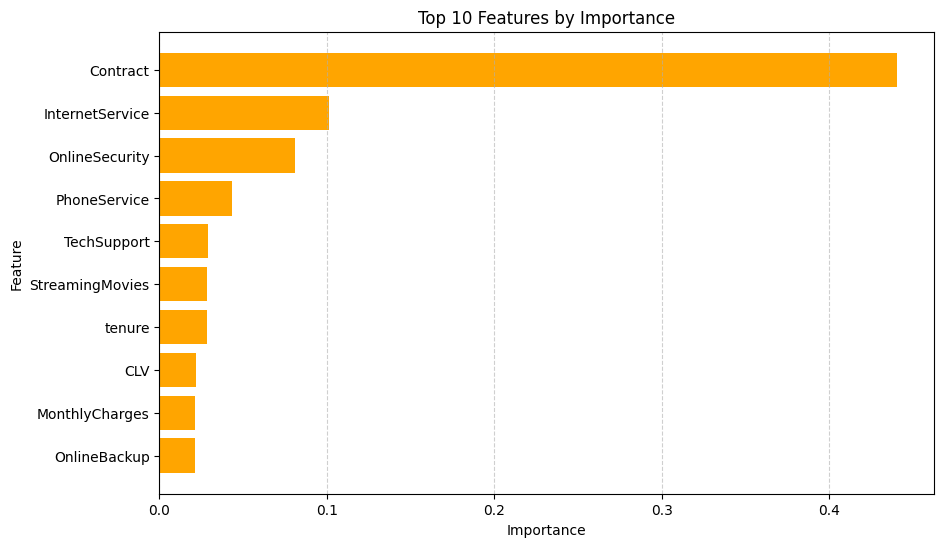

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(xgb, max_num_features=10, importance_type='gain', color='blue')
plt.title('Top 10 Important Features (XGBoost)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'][:10], feature_importances['Importance'][:10], color='orange')
plt.gca().invert_yaxis()
plt.title('Top 10 Features by Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


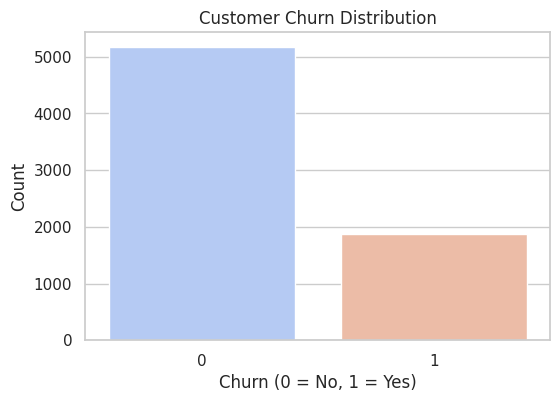

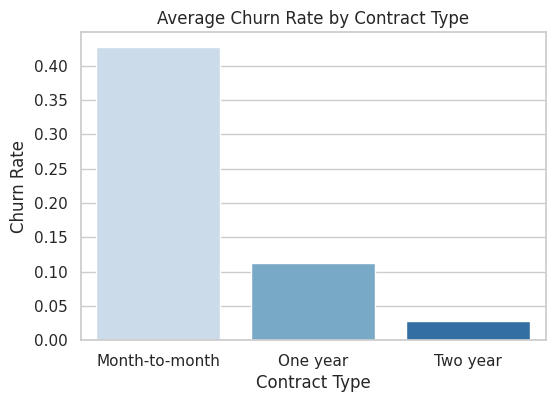

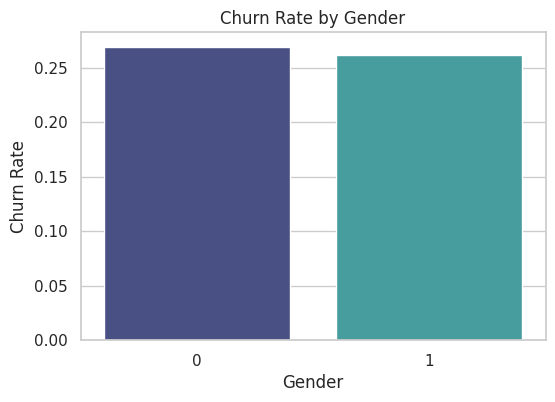

<Figure size 1000x600 with 0 Axes>

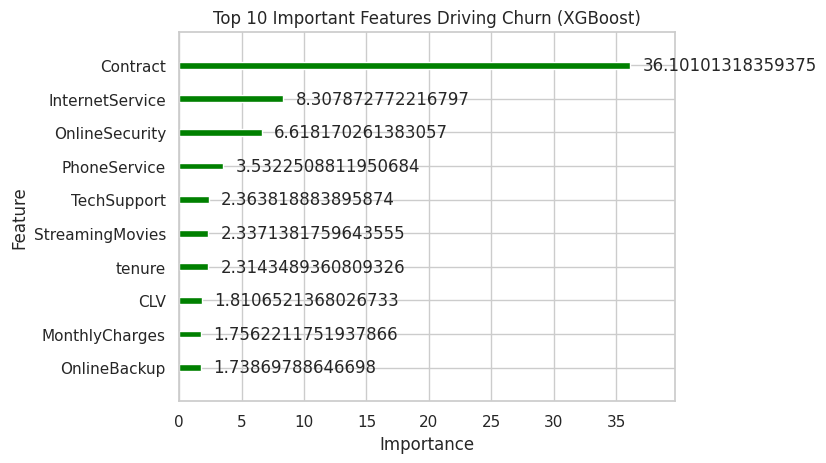

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import plot_importance


sns.set_theme(style='whitegrid')

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, hue='Churn', legend=False, palette='coolwarm')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

churn_contract = df.groupby('Contract')['Churn'].mean().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(x='Contract', y='Churn', data=churn_contract, hue='Contract', legend=False, palette='Blues')
plt.title('Average Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.show()

churn_gender = df.groupby('gender')['Churn'].mean().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(x='gender', y='Churn', data=churn_gender, hue='gender', legend=False, palette='mako')
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.xlabel('Gender')
plt.show()

plt.figure(figsize=(10, 6))
plot_importance(xgb, max_num_features=10, importance_type='gain', color='green')
plt.title('Top 10 Important Features Driving Churn (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [ ]:

df_dashboard = df[[
    'customerID', 'Gender_Label', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
    'CLV', 'Churn', 'Churn_Rate', 'RF_Churn_Prob', 'Log_Churn_Prob', 'XGB_Churn_Prob'
]]

file_name = "Telco_Churn DashboardData.csv"
df_dashboard.to_csv(file_name, index=False)
print("Exported:", file_name)


Exported: Telco_Churn DashboardData.csv


In [ ]:

try:
    from google.colab import files
    files.download(file_name)
except Exception:
    pass


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>